In [1]:
import numpy as np
import qutip as qt
from qutip.control.pulseoptim import optimize_pulse_unitary
import matplotlib.pyplot as plt
from scipy.optimize import minimize


MHz = 1  # conversion: 1 MHz → rad/s
B0 = 0.033  # 33 mT
D = 1352 * MHz
gamma_e = 28.024e3 * MHz  # electron gyromagnetic (rad/s/T)
gamma_Si = -8.465 * MHz  # 29Si gyromagnetic (rad/s/T)
A_zz = 12.15 * MHz  # hyperfine coupling
delta_f = A_zz / 2    # f2-f1
# omega_max = 200 * MHz  # maximum Rabi

n_ts = 100  # number of time slots
dt = 5e-3  # us per slot
T = n_ts * dt  # total pulse duration
t_list = np.arange(n_ts) * dt

# Pauli matrices
sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()

# Define tensor-product operators (electron ⊗ nucleus)
Sx = [qt.tensor(sx/2, 1/2*(qt.qeye(2)+sz)), qt.tensor(sx/2, 1/2*(qt.qeye(2)-sz))]
Sy = [qt.tensor(sy/2, 1/2*(qt.qeye(2)+sz)), qt.tensor(sy/2, 1/2*(qt.qeye(2)-sz))]


def H_t(w):
    w1 = w  # Δ1
    w2 = w - 4 * np.pi * delta_f  # Δ2
    # w3 = w + 2 * np.pi * delta_f
    # w4 = w - 2 * np.pi * delta_f
    return [[np.cos(w1*t)*Sx[0] + np.sin(w1*t)*Sy[0] + np.cos(w2*t)*Sx[1] + np.sin(w2*t)*Sy[1],
             -np.sin(w1*t)*Sx[0] + np.cos(w1*t)*Sy[0] + -np.sin(w2*t)*Sx[1] + np.cos(w2*t)*Sy[1]] for t in t_list]


H_d = 0*qt.tensor(qt.qeye(2), qt.qeye(2))
U0 = qt.tensor(qt.qeye(2), qt.qeye(2))
U_electron = sx
U_target = qt.tensor(U_electron, qt.qeye(2))
# U_target = qt.tensor(-qt.qeye(2), 1/2*(qt.qeye(2)+sz)) + qt.tensor(qt.qeye(2), 1/2*(qt.qeye(2)-sz))
# U_target = qt.tensor(sx, 1/2*(qt.qeye(2)+sz)) + qt.tensor(qt.qeye(2), 1/2*(qt.qeye(2)-sz))
# U_target = qt.Qobj(np.array([[0, 0, -1j, 0],
#                 [0, 1, 0, 0],
#                 [-1j, 0, 0, 0],
#                 [0, 0, 0, 1]]),
#                 dims=[[2, 2], [2, 2]])



C:\Users\David\AppData\Local\Temp\ipykernel_31472\3511049245.py:2: DeprecationWarning: The 'amp_update_mode' parameter is deprecated. Use 'tslot_type' instead
  result = optimize_pulse_unitary(


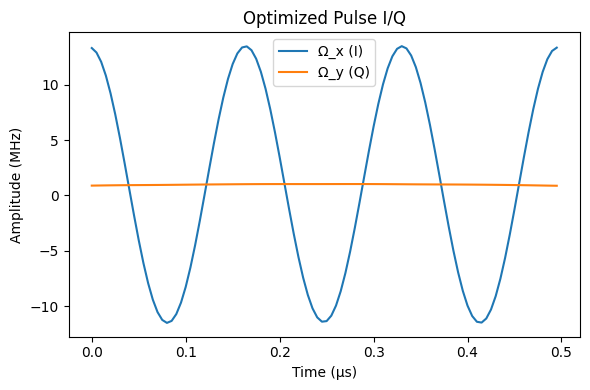

Final fidelity            : 1.000000
Max amplitude (MHz)       : 13.501
Max ΔΩ per slot (MHz)      : 0.4
Number of iterations      : 3
Final gradient norm       : 9.253e-05
Termination reason        : Goal achieved


In [2]:
def opu(sigma_f=0.0):
    result = optimize_pulse_unitary(
        H_d, H_t(2 * np.pi * (sigma_f + delta_f)), U0, U_target,
        num_tslots=n_ts,
        evo_time=T,
        fid_err_targ=1e-5,
        max_iter=100000,  # allow more steps
        init_pulse_type='GAUSSIAN',  # <-- random start
        init_pulse_params={'seed': 47},
        alg='GRAPE',  # default
        phase_option='PSU',  # ignore global phase
        amp_update_mode='ALL',  # update every slot each iter
        ramping_pulse_type='GAUSSIAN',  # smooth envelope (hardware-friendly)
        ramping_pulse_params={'std': 10},  # std in slots
    )
    return result


t_us = np.arange(n_ts) * dt

result = opu()
omega_x_opt = result.final_amps[:, 0]
omega_y_opt = result.final_amps[:, 1]
omega_x_MHz = omega_x_opt
omega_y_MHz = omega_y_opt

plt.figure(figsize=(6, 4))
plt.plot(t_us, omega_x_MHz, label='Ω_x (I)')
plt.plot(t_us, omega_y_MHz, label='Ω_y (Q)')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (MHz)')
plt.title('Optimized Pulse I/Q')
plt.legend()
plt.tight_layout()
plt.show()

# Print metrics
fidelity = 1 - result.fid_err
max_amp_MHz = max(omega_x_MHz.max(), omega_y_MHz.max())
delta_slots_x = np.diff(omega_x_MHz, axis=0)
delta_slots_y = np.diff(omega_y_MHz, axis=0)
max_domega = max(np.max(np.abs(delta_slots_x)), np.max(np.abs(delta_slots_y))) / (2 * np.pi)  # in Hz

print(f"Final fidelity            : {fidelity:.6f}")
print(f"Max amplitude (MHz)       : {max_amp_MHz:.3f}")
print(f"Max ΔΩ per slot (MHz)      : {max_domega:.1f}")
print(f"Number of iterations      : {result.num_iter}")
print(f"Final gradient norm       : {result.grad_norm_final:.3e}")
print(f"Termination reason        : {result.termination_reason}")


In [3]:
def build_controls(Delta1_MHz, Delta2_MHz):
    """Devuelve (Hx_list, Hy_list) con longitud n_ts, para usar con tslot_type='DEF'."""
    w1 = 2 * np.pi * Delta1_MHz  # rad/us
    w2 = 2 * np.pi * Delta2_MHz  # rad/us
    Hx_list, Hy_list = [], []
    for t in t_list:
        c1, s1 = np.cos(w1*t), np.sin(w1*t)
        c2, s2 = np.cos(w2*t), np.sin(w2*t)
        Hx = c1*Sx[0] + s1*Sy[0] + c2*Sx[1] + s2*Sy[1]
        Hy = -s1*Sx[0] + c1*Sy[0] - s2*Sx[1] + c2*Sy[1]
        Hx_list.append(Hx); Hy_list.append(Hy)
    return Hx_list, Hy_list


def fidelity_with_noise_piecewise(final_amps=result.final_amps, sigma_f=0.0, amp_fluc=0.0, amp_mode='mul'):
    """Compute average gate fidelity by manual piecewise propagation."""
    # Build angular detunings per Rui: BOTH deltas shift by +sigma_f
    Hx_list, Hy_list = build_controls(delta_f+sigma_f, -delta_f+sigma_f)
    U = qt.Qobj(np.eye(U0.shape[0]), dims=U0.dims)  # identity with same dims
    for k in range(n_ts):
        ax, ay = final_amps[k, 0], final_amps[k, 1]
        if amp_mode == 'mul':
            ax *= (1.0 + amp_fluc)
            ay *= (1.0 + amp_fluc)
        elif amp_mode == 'add':
            ax += amp_fluc
            ay += amp_fluc
        Hk = H_d + ax*Hx_list[k] + ay*Hy_list[k]
        U = (-(1j)*Hk*dt).expm() * U

    F = qt.average_gate_fidelity(U, U_target)
    return float(np.real_if_close(F))


# Sanity checks
print("No-noise fidelity (helper):", fidelity_with_noise_piecewise(sigma_f=0.0, amp_fluc=0.0, amp_mode='add'))
print("noise fidelity (helper):", fidelity_with_noise_piecewise(sigma_f=0.1, amp_fluc=0.0, amp_mode='add'))


init_amps = opu().final_amps



No-noise fidelity (helper): 0.9999997236862594
noise fidelity (helper): 0.9726706152439455


C:\Users\David\AppData\Local\Temp\ipykernel_31472\3511049245.py:2: DeprecationWarning: The 'amp_update_mode' parameter is deprecated. Use 'tslot_type' instead
  result = optimize_pulse_unitary(


Best fidelity at |δ|=0.1: F = 0.9966 with params [ 3.71862708  2.06634382  2.3413262   0.50624962 -0.31092083 -0.41511159
 -0.21898289 -0.25730521]
F(δ=+0.000) = 0.9993
F(δ=+0.050) = 0.9986
F(δ=-0.050) = 0.9986
F(δ=+0.100) = 0.9965
F(δ=-0.100) = 0.9966


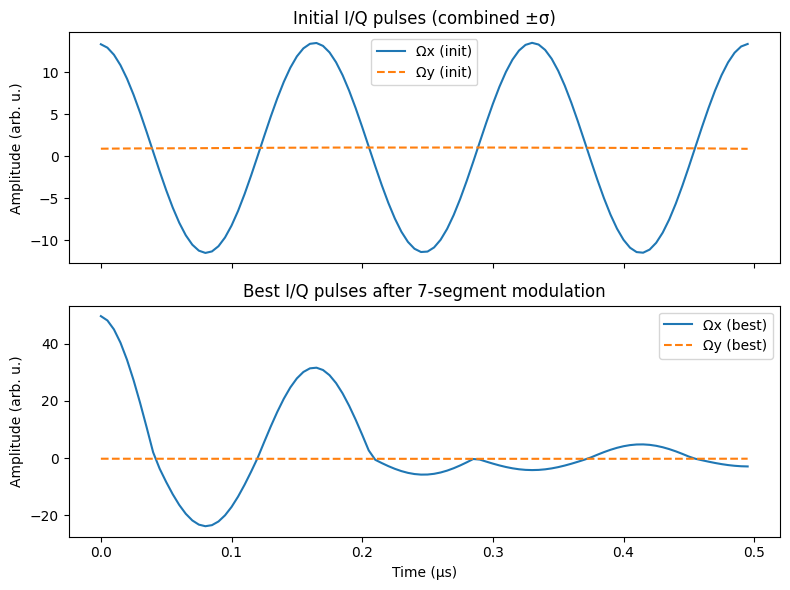

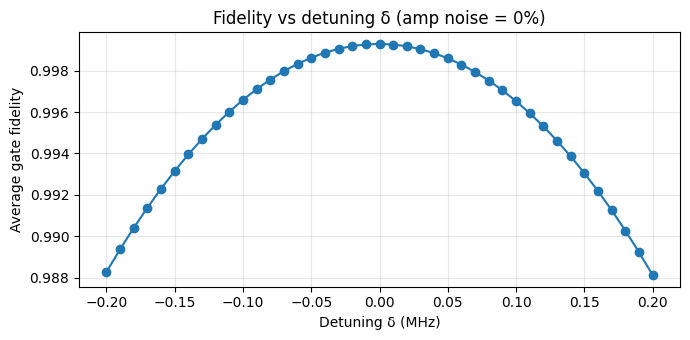

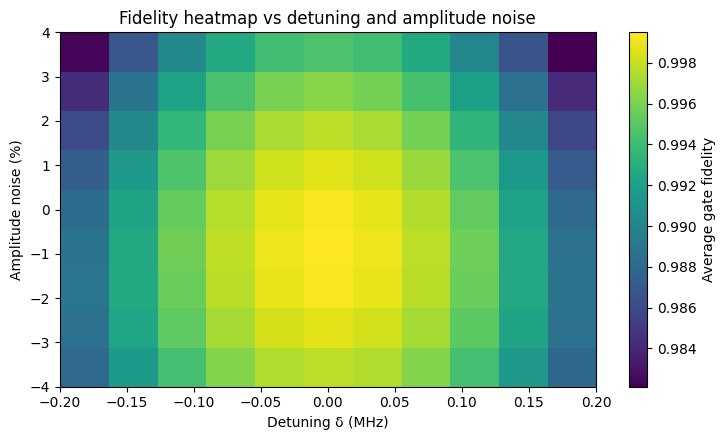

In [4]:
def modulate_fourier(amps, modulation_params):
    n = amps.shape[0]
    A = np.zeros((n, 2))
    j = 0

for i in range(2):
    arr = amps[:, i]
    current_sign = 1 if arr[0] >= 0 else -1
    segments = []  # store the segments
    current_segment = []  # current segment
    for num in arr:
        sign = 1 if num >= 0 else -1

        # if the sign changes, start a new segment
        if sign != current_sign:
            segments.append(current_segment)
            current_segment = [num]
            current_sign = sign
        else:
            current_segment.append(num)

    # add the last segment
    if current_segment:
        segments.append(current_segment)

    # multiply each segment by a random number and recombine
    modulated_segments = []
    for segment in segments:
        modulated_segment = [x * modulation_params[j] for x in segment]
        modulated_segments.extend(modulated_segment)
        j += 1

    # print(random_factors)
    A[:, i] = modulated_segments

# return np.column_stack((amps[:, 0], amps[:, 1]))
return A



def func_to_maximize(modulation_params):
    modulated_amps = modulate_fourier(init_amps, modulation_params)
    fidelity_1 = fidelity_with_noise_piecewise(sigma_f=0.1, amp_fluc=0.0, final_amps=modulated_amps, amp_mode='scale')
    fidelity_2 = fidelity_with_noise_piecewise(sigma_f=-0.1, amp_fluc=0.0, final_amps=modulated_amps, amp_mode='scale')
    return -0.5 * (fidelity_1 + fidelity_2)


optimized_result = minimize(func_to_maximize, np.ones(8), method='Nelder-Mead',
                            options={'maxiter': 100, 'xatol': 1e-3, 'fatol': 1e-4, 'disp': False})
best_F, best_params, best_amps = -optimized_result.fun, optimized_result.x, modulate_fourier(init_amps, optimized_result.x)


print(f"Best fidelity at |δ|={0.1}: F = {best_F:.4f} with params {best_params}")

# Also check around δ = 0 and ±0.1 for context
for d in [0.0, +0.05, -0.05, +0.1, -0.1]:
    Fd = fidelity_with_noise_piecewise(sigma_f=d, amp_fluc=0.0, final_amps=best_amps)
    print(f"F(δ={d:+.3f}) = {Fd:.4f}")




In [ ]:
# 1) I/Q time traces: before vs after modulation
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_list, init_amps[:,0], label='Ωx (init)')
ax[0].plot(t_list, init_amps[:,1], label='Ωy (init)', linestyle='--')
ax[0].set_title('Initial I/Q pulses (combined ±σ)')
ax[0].set_ylabel('Amplitude (arb. u.)')
ax[0].legend(loc='best')

ax[1].plot(t_list, best_amps[:,0], label='Ωx (best)')
ax[1].plot(t_list, best_amps[:,1], label='Ωy (best)', linestyle='--')
ax[1].set_title('Best I/Q pulses after 7-segment modulation')
ax[1].set_xlabel('Time (μs)')
ax[1].set_ylabel('Amplitude (arb. u.)')
ax[1].legend(loc='best')
plt.tight_layout()
plt.show()

# 4) Fidelity vs detuning (δ sweep at zero amp noise)
deltas = np.linspace(-0.2, 0.2, 41)  # MHz
F_vs_d = []
for d in deltas:
    Fd = fidelity_with_noise_piecewise(final_amps=best_amps, sigma_f=d, amp_fluc=0.0, amp_mode='mul')
    F_vs_d.append(Fd)
F_vs_d = np.array(F_vs_d)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(deltas, F_vs_d, marker='o')
ax.set_title('Fidelity vs detuning δ (amp noise = 0%)')
ax.set_xlabel('Detuning δ (MHz)')
ax.set_ylabel('Average gate fidelity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5) 2D heatmap: Fidelity vs (δ, amplitude noise)
deltas_grid = np.linspace(-0.2, 0.2, 11)  # MHz
amp_noises  = np.linspace(-0.04, 0.04, 9)    # 0% to 2% multiplicative
F_map = np.zeros((len(amp_noises), len(deltas_grid)))

for i, eps in enumerate(amp_noises):
    for j, d in enumerate(deltas_grid):
        F_map[i, j] = fidelity_with_noise_piecewise(final_amps=best_amps, sigma_f=d, amp_fluc=eps, amp_mode='mul')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(F_map, aspect='auto', origin='lower',
               extent=[deltas_grid[0], deltas_grid[-1], amp_noises[0]*100, amp_noises[-1]*100],
               vmin=np.min(F_map), vmax=np.max(F_map))
ax.set_title('Fidelity heatmap vs detuning and amplitude noise')
ax.set_xlabel('Detuning δ (MHz)')
ax.set_ylabel('Amplitude noise (%)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Average gate fidelity')
plt.tight_layout()
plt.show()
